<a href="https://colab.research.google.com/github/deveveryday/dsai_labda/blob/main/5_API_Consume_part2__Justino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Figura](attachment:image.png)

In [53]:
import os
from getpass import getpass
from urllib.parse import urlencode

import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 50)

## 1. Uma função auxiliar para requisições GET

Método básico para fazer uma requisição

```python
resposta = requests.get(url,params,headers,timeout)
```

Praa facilitar as próximas etapas, vamos criar uma função para:

1. enviar a requisição;
2. definir um tempo máximo de espera;
3. verificar o código de status;
4. gerar uma exceção quando a resposta HTTP indicar erro.

O parâmetro `timeout` evita que o notebook aguarde indefinidamente por um servidor que não responde.

In [54]:
def requisicao_get(url, params=None, headers=None, timeout=20):
    resposta = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=timeout
    )

    print("Status HTTP:", resposta.status_code)
    resposta.raise_for_status()

    return resposta

# 2. APIs com autenticação

Agora estudaremos serviços que exigem uma credencial para os exemplos propostos.

Nesta aula, a expressão **API com autenticação** será usada para indicar uma integração em que a requisição depende de uma credencial, como:

- API Key;
- access token;
- OAuth 2.0.

Isso não significa que todos os dados fornecidos pelo serviço sejam necessariamente privados. O ponto central é que o servidor precisa identificar ou autorizar o cliente antes de processar a operação utilizada no exemplo.

## 2.1. Nunca escreva segredos diretamente no notebook

Evite:

```python
TOKEN = "meu_token_real"
```

Um notebook pode ser:

- enviado a outra pessoa;
- publicado no GitHub;
- armazenado em nuvem;
- incluído em backups;
- exibido durante uma aula.

Nesta aula, utilizaremos `getpass()` para digitação temporária. Em projetos reais, prefira mecanismos apropriados de gerenciamento de segredos ou variáveis de ambiente.

# 3. API do Mercado Livre: configuração, OAuth e busca de produtos

Nesta seção, a configuração será feita **na mesma ordem em que o código será construído**. A finalidade é reduzir erros de autenticação e tornar o procedimento reproduzível em sala de aula.

Ao final, faremos uma busca por **Smart TV 70** no catálogo do Mercado Livre e transformaremos os produtos retornados em um `DataFrame`.

Documentação oficial consultada:

- criação da aplicação: https://developers.mercadolivre.com.br/pt_br/crie-uma-aplicacao-no-mercado-livre
- autenticação e autorização: https://developers.mercadolivre.com.br/autenticacao-e-autorizacao
- buscador de produtos: https://developers.mercadolivre.com.br/buscador-de-produtos

> A interface do DevCenter pode mudar. Os nomes exatos dos campos podem sofrer pequenas alterações, mas os conceitos de `Client ID`, `Client Secret`, `Redirect URI`, escopos e OAuth permanecem.


## 3.1. Acesso o DevCenter e clique em Criar nova aplicação

![Figura](attachment:image.png)

## 3.2. Preencha os dados e insira um logotipo qualquer.

![Figura](attachment:image-2.png)

## 3.3. Adicione uma URI

![Figura](attachment:image-3.png)

## 3.4. O que será configurado no DevCenter

Para esta aula, configure uma aplicação **somente para leitura**. Não precisamos publicar produtos, alterar anúncios ou receber notificações.

Preencha os campos da aplicação da seguinte forma:

| Campo no Mercado Livre | Configuração didática sugerida | Finalidade |
|---|---|---|
| **Nome** | `Aula API Mercado Livre` | Identificar a aplicação |
| **Nome curto** | um identificador simples e único | Identificação interna/URL da aplicação |
| **Descrição** | `Aplicação didática para consulta de produtos via API` | Texto apresentado no processo de autorização |
| **Logo** | opcional, conforme a interface permitir | Identificação visual |
| **Redirect URI** | `https://example.com` | Receber o retorno com o `code` |
| **PKCE** | desabilitado nesta primeira aula | Evita adicionar uma segunda camada ao fluxo didático |
| **Escopo Leitura** | habilitado | Necessário para chamadas `GET` |
| **Escopo Escrita** | desabilitado | Não será utilizado |
| **Tópicos/Notificações** | nenhum | Não precisamos receber eventos de Orders, Items, Catalog etc. |
| **URL de notificações** | não configurar | Só é necessária quando tópicos são selecionados |

### Por que usar `https://example.com`?

O Mercado Livre exige uma URI de redirecionamento com HTTPS. Para a aula, podemos utilizar uma URL de teste. Depois da autorização, observe a **barra de endereço do navegador**: o Mercado Livre acrescentará o parâmetro `code` à URL.

Exemplo conceitual:

```text
https://example.com/?code=TG-XXXXXXXXXXXX&state=YYYY
```

Mesmo que a página de destino não seja utilizada pela aplicação, o que nos interessa didaticamente é copiar o valor de `code` exibido na URL.

**Regra crítica:** use exatamente a mesma Redirect URI em três lugares:

1. cadastro da aplicação;
2. URL de autorização;
3. requisição que troca o `code` pelo token.

## 3.5. Resultado esperado
![Figura](attachment:image-4.png)

## 3.6. Depois de salvar a aplicação: identifique as credenciais

Após criar a aplicação, localize no DevCenter:

- **Client ID / APP ID**: identifica publicamente sua aplicação;
- **Client Secret / Secret Key**: segredo da aplicação;
- **Redirect URI**: endereço cadastrado anteriormente.

Nesta aula, o `Client Secret` nunca será escrito diretamente no notebook. Ele será solicitado por `getpass()`.

## 4. Construir o a URL de busca
## 4.1. registrar somente o Client ID e a Redirect URI

Começamos com os dois valores que **não são o token**. Nesta etapa ainda não faremos nenhuma requisição à API.


In [55]:
app_id_ml = input("APP ID / Client ID do Mercado Livre: ").strip()
redirect_uri_ml = input("Redirect URI cadastrada [https://example.com]: ").strip()

if not redirect_uri_ml: redirect_uri_ml = "https://example.com"

print("APP ID informado:", app_id_ml)
print("Redirect URI:", redirect_uri_ml)


APP ID / Client ID do Mercado Livre: 4123220868366020
Redirect URI cadastrada [https://example.com]: https://example.com
APP ID informado: 4123220868366020
Redirect URI: https://example.com


## 4.2. Etapa 2: construir a URL de autorização

A URL de autorização é formada por um **endpoint fixo** e **parâmetros variáveis**.

Para o Brasil:

```text
https://auth.mercadolivre.com.br/authorization
```

Parâmetros utilizados:

- `response_type=code`: solicita um código de autorização;
- `client_id`: APP ID da aplicação;
- `redirect_uri`: deve coincidir exatamente com o cadastro;
- `state`: valor aleatório usado para associar a resposta à solicitação iniciada.

Em vez de montar a URL manualmente, utilizaremos `urlencode()`. Isso evita erros com caracteres especiais.


In [56]:
import secrets

state_ml = secrets.token_urlsafe(16)

parametros_autorizacao_ml = {
    "response_type": "code",
    "client_id": app_id_ml,
    "redirect_uri": redirect_uri_ml,
    "state": state_ml
}

url_autorizacao_ml = ("https://auth.mercadolivre.com.br/authorization?" + urlencode(parametros_autorizacao_ml))

print("Abra a URL abaixo no navegador:\n")
print(url_autorizacao_ml)
print("\nState gerado:", state_ml)


Abra a URL abaixo no navegador:

https://auth.mercadolivre.com.br/authorization?response_type=code&client_id=4123220868366020&redirect_uri=https%3A%2F%2Fexample.com&state=l42Z3uAKTTvtcl48oedsMg

State gerado: l42Z3uAKTTvtcl48oedsMg


## 4.3. Acesse o link gerado e a autorize a aplicação
![Figura](attachment:image.png)

## 4.4. autorizar no navegador e copiar o `code`

Agora o processo sai temporariamente do Python.

1. copie a URL produzida pela célula anterior;
2. abra-a no navegador;
3. faça login com a conta proprietária da aplicação;
4. autorize a aplicação;
5. aguarde o redirecionamento;
6. observe a URL final na barra de endereço;
7. copie somente o valor depois de `code=` e antes de `&state=`.

Exemplo:

```text
https://example.com/?code=TG-ABC123&state=XYZ456
```

Nesse exemplo:

```text
code  = TG-ABC123
state = XYZ456
```

O `code` é temporário e de uso único. Ele **ainda não é o access token**.


## 4.5. Trocar o `code` pelo access token

A troca é feita com uma requisição `POST` para:

```text
https://api.mercadolibre.com/oauth/token
```

Agora precisamos do `Client Secret`, por isso ele será digitado com `getpass()`.

> Se ocorrer `invalid_grant`, verifique primeiro: `code` já utilizado/expirado, Redirect URI diferente da cadastrada ou `code` pertencente a outra tentativa de autorização.


In [57]:
client_secret_ml = getpass("Client Secret do Mercado Livre: ")
authorization_code_ml = getpass("Authorization code recebido: ")

url_token_ml = "https://api.mercadolibre.com/oauth/token"

dados_token_ml = {
    "grant_type": "authorization_code",
    "client_id": app_id_ml,
    "client_secret": client_secret_ml,
    "code": authorization_code_ml,
    "redirect_uri": redirect_uri_ml
}

resposta_token_ml = requests.post(
    url_token_ml,
    data=dados_token_ml,
    headers={
        "accept": "application/json",
        "content-type": "application/x-www-form-urlencoded"
    },
    timeout=20
)

print("Status HTTP:", resposta_token_ml.status_code)
resposta_token_ml.raise_for_status()

token_data_ml = resposta_token_ml.json()

print("Access token recebido:", "access_token" in token_data_ml)
print("Tipo:", token_data_ml.get("token_type"))
print("Expira em segundos:", token_data_ml.get("expires_in"))
print("Escopos:", token_data_ml.get("scope"))


Client Secret do Mercado Livre: ··········
Authorization code recebido: ··········
Status HTTP: 200
Access token recebido: True
Tipo: Bearer
Expira em segundos: 21600
Escopos: read urn:global:admin:info:/read-only urn:global:admin:info:/read-write urn:global:admin:oauth:/read-only urn:global:admin:oauth:/read-write urn:global:admin:users:/read-only urn:ml:all:comunication:/read-only urn:ml:all:publish-sync:/read-only urn:ml:mktp:ads:/read-only urn:ml:mktp:comunication:/read-only urn:ml:mktp:invoices:/read-only urn:ml:mktp:metrics:/read-only urn:ml:mktp:offers:/read-only urn:ml:mktp:orders-shipments:/read-only urn:ml:mktp:publish-sync:/read-only write


## 4.6. Preparar o header de autenticação

A partir deste ponto, não precisamos colocar o token na URL. O Mercado Livre recomenda enviá-lo no header HTTP:

```text
Authorization: Bearer ACCESS_TOKEN
```

Essa configuração poderá ser reutilizada em todas as próximas chamadas autenticadas.


In [58]:
access_token_ml = token_data_ml["access_token"]

headers_ml = {"Authorization": f"Bearer {access_token_ml}"}

print("Header preparado. O token não será exibido.")


Header preparado. O token não será exibido.


## 5. Teste mínimo de autenticação

Antes de construir uma consulta maior, fazemos uma chamada pequena a `/users/me`.

Objetivo desta célula: responder apenas à pergunta **"o token funciona?"**.


In [59]:
resposta_usuario_ml = requisicao_get("https://api.mercadolibre.com/users/me", headers=headers_ml)

usuario_ml = resposta_usuario_ml.json()

print("Usuário autenticado:", usuario_ml.get("nickname"))
print("Site:", usuario_ml.get("site_id"))
print("ID:", usuario_ml.get("id"))


Status HTTP: 200
Usuário autenticado: SKATEEVERYDAY
Site: MLB
ID: 6414


## 6. Buscar produtos do catálogo

Agora utilizaremos um endpoint adequado para pesquisa textual de **produtos de catálogo**:

```text
GET https://api.mercadolibre.com/products/search
```

Parâmetros principais:

- `site_id=MLB`: Brasil;
- `status=active`: produtos ativos;
- `q`: texto de busca;
- `limit`: número de resultados;
- `offset`: posição inicial para paginação.

Vamos pesquisar:

```text
Smart TV 70
```

Observe que o retorno não é uma tabela. A resposta possui metadados de paginação e uma lista em `results`.


In [60]:
url_busca_ml = "https://api.mercadolibre.com/products/search"

parametros_busca_ml = {
    "site_id": "MLB",
    "status": "active",
    "q": "shape skate",
    "limit": 20,
    "offset": 0
}

resposta_busca_ml = requisicao_get(
    url_busca_ml,
    params=parametros_busca_ml,
    headers=headers_ml
)

busca_ml = resposta_busca_ml.json()

print("Termo pesquisado:", busca_ml.get("keywords"))
print("Total informado pela API:", busca_ml.get("paging", {}).get("total"))
print("Resultados nesta página:", len(busca_ml.get("results", [])))


Status HTTP: 200
Termo pesquisado: shape skate
Total informado pela API: 10000
Resultados nesta página: 20


## 6.1. Inspecionar a estrutura antes de criar o DataFrame

Antes de usar `pd.json_normalize()`, examine as chaves do primeiro produto. Essa prática evita selecionar colunas que não existem.


In [61]:
resultados_ml = busca_ml.get("results", [])

if resultados_ml:
    print("Campos do primeiro produto:")
    print(list(resultados_ml[0].keys()))
else:
    print("Nenhum produto retornado para a consulta.")


Campos do primeiro produto:
['attributes', 'authority_types', 'catalog_product_id', 'children_ids', 'date_created', 'domain_id', 'id', 'last_updated', 'name', 'parent_id', 'pictures', 'product_standard', 'quality_type', 'search_type', 'settings', 'short_description', 'status', 'tags']


## 6.2. Transformar os resultados em um DataFrame

A lista `results` é a parte da resposta que corresponde ao conjunto de produtos. Como alguns campos são aninhados, utilizaremos `pd.json_normalize()`.

Neste primeiro DataFrame manteremos os atributos de nível principal. Depois criaremos colunas específicas como marca e modelo.


In [62]:
df_produtos_ml = pd.json_normalize(resultados_ml)

print("Dimensão:", df_produtos_ml.shape)
df_produtos_ml.head()


Dimensão: (20, 21)


,attributes,authority_types,catalog_product_id,children_ids,date_created,domain_id,...,tags,settings.content,settings.exclusive,settings.listing_strategy,short_description.content,short_description.type
0,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB78948323,[],2026-09-04T23:59:16Z,MLB-KID_SKATEBOARDS,...,[],fixed,False,catalog_required,,plaintext
1,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB38579024,[],2024-07-23T11:12:25Z,MLB-COMPLETE_SKATEBOARDS,...,[],fixed,False,catalog_required,Shape Skate Black Sheep Feminino 8.0\n\nShape ...,plaintext
2,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB73849304,[],2026-06-16T16:38:52Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,O Shape Skate Maple Grizzly 8.25 Wildlife comb...,plaintext
3,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB66303097,[],2026-03-07T08:24:14Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,"Shape enviado lixado, sem verniz e pronto para...",plaintext
4,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB74256092,[],2026-06-20T16:40:00Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,"O shape de skate modelo Wildlife, desenvolvido...",plaintext


## 6.4. Extrair atributos como marca, modelo e tamanho da tela

No retorno do catálogo, características técnicas costumam aparecer dentro de `attributes`, uma lista de objetos.

Em vez de manter essa lista inteira em uma célula, criaremos uma função para procurar um atributo pelo seu `id`.

IDs frequentemente úteis para televisores incluem `BRAND`, `MODEL` e atributos relacionados ao tamanho da tela. Como a estrutura pode variar entre produtos, o código utiliza uma lista de alternativas para o tamanho.


In [63]:
def valor_atributo(lista_atributos, ids_procurados):
    if not isinstance(lista_atributos, list):
        return None

    ids_procurados = set(ids_procurados)

    for atributo in lista_atributos:
        if atributo.get("id") in ids_procurados:
            return atributo.get("value_name")

    return None

if not df_produtos_ml.empty:
    df_produtos_ml["marca"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["BRAND"])
    )
    df_produtos_ml["modelo"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["MODEL"])
    )
    df_produtos_ml["tamanho_tela"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(
            x,
            ["SCREEN_SIZE", "DISPLAY_SIZE", "TV_SIZE"]
        )
    )

    colunas_ml = [
        "id", "name", "status", "domain_id",
        "marca", "modelo", "tamanho_tela"
    ]

    df_produtos_ml_base = df_produtos_ml[
        [c for c in colunas_ml if c in df_produtos_ml.columns]
    ].copy()
else:
    df_produtos_ml_base = pd.DataFrame()

df_produtos_ml_base


,id,name,status,domain_id,marca,modelo,tamanho_tela
0,MLB78948323,Skate Infantil Juvenil 24 Unissex Shape Skate ...,active,MLB-KID_SKATEBOARDS,ImportWay,BW553S,None
1,MLB38579024,Shape Skate Black Sheep Feminino 8.0,active,MLB-COMPLETE_SKATEBOARDS,Black Sheep,Feminino 8.0,None
2,MLB73849304,Shape Skate Maple Grizzly 8.25 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,None
3,MLB66303097,Shape Skate Decoração Pintura Desenho,active,MLB-SKATEBOARD_DECKS,KSB,DECORAÇÃO,None
4,MLB74256092,Shape Skate Maple Grizzly 8.0 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,None
5,MLB47726459,Shape Skate Marfim Hip Hop Hideout,active,MLB-SKATEBOARD_DECKS,Hideout,Hip Hop Marfim,None
6,MLB74034437,Shape Skate Maple Grizzly 8.1 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,None
7,MLB73225650,Shape Skate Maple Grizzly 8.5 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,None
8,MLB73584850,Shape Skate Flip 8.1 Maple Cor Camuflado,active,MLB-SKATEBOARD_DECKS,Flip,81,None
9,MLB74043147,Shape Skate Kick K1 Maple - K 8.12,active,MLB-SKATEBOARD_DECKS,Kick Skateboards,K1 Maple,None


## 6.5. Obter detalhes dos produtos encontrados

A busca fornece uma lista resumida. Para aprofundar a coleta, podemos consultar cada `product_id` em:

```text
GET https://api.mercadolibre.com/products/{PRODUCT_ID}
```

O detalhe pode incluir `permalink`, `family_name`, atributos técnicos, imagens e informações da oferta vencedora (`buy_box_winner`) quando disponíveis.

Para não gerar muitas requisições em sala, consultaremos apenas os cinco primeiros produtos.


In [64]:
detalhes_produtos_ml = []

for product_id in df_produtos_ml_base.get("id", pd.Series(dtype=str)).head(5):
    resposta = requisicao_get(
        f"https://api.mercadolibre.com/products/{product_id}",
        headers=headers_ml
    )
    detalhes_produtos_ml.append(resposta.json())

print("Produtos detalhados:", len(detalhes_produtos_ml))


Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Produtos detalhados: 5


In [65]:
linhas_detalhes_ml = []

for produto in detalhes_produtos_ml:
    vencedor = produto.get("buy_box_winner") or {}

    linhas_detalhes_ml.append({
        "product_id": produto.get("id"),
        "nome": produto.get("name"),
        "familia": produto.get("family_name"),
        "status": produto.get("status"),
        "dominio": produto.get("domain_id"),
        "preco_oferta_vencedora": vencedor.get("price"),
        "moeda": vencedor.get("currency_id"),
        "frete_gratis": (vencedor.get("shipping") or {}).get("free_shipping"),
        "permalink": produto.get("permalink")
    })

df_detalhes_ml = pd.DataFrame(linhas_detalhes_ml)
df_detalhes_ml


,product_id,nome,familia,status,dominio,preco_oferta_vencedora,moeda,frete_gratis,permalink
0,MLB78948323,Skate Infantil Juvenil 24 Unissex Shape Skate ...,Skate infantil ImportWay BW553S,active,MLB-KID_SKATEBOARDS,None,None,None,
1,MLB38579024,Shape Skate Black Sheep Feminino 8.0,Skate completo Black Sheep Feminino 8.0,active,MLB-COMPLETE_SKATEBOARDS,None,None,None,
2,MLB73849304,Shape Skate Maple Grizzly 8.25 Wildlife,Shape de skate Grizzly Maple,active,MLB-SKATEBOARD_DECKS,None,None,None,
3,MLB66303097,Shape Skate Decoração Pintura Desenho,Shape de skate KSB DECORAÇÃO,active,MLB-SKATEBOARD_DECKS,None,None,None,
4,MLB74256092,Shape Skate Maple Grizzly 8.0 Wildlife,Shape de skate Grizzly Maple,active,MLB-SKATEBOARD_DECKS,None,None,None,


## 6.6. Paginação da busca

O Mercado Livre utiliza `offset` e `limit` neste recurso. A ideia é deslocar a janela de resultados:

```text
offset=0   → primeira página
offset=20  → segunda página
offset=40  → terceira página
```

A função abaixo reúne várias páginas em um único DataFrame.


In [66]:
def buscar_produtos_ml(termo, paginas=3, limite=20):
    produtos = []

    for pagina in range(paginas):
        params = {
            "site_id": "MLB",
            "status": "active",
            "q": termo,
            "limit": limite,
            "offset": pagina * limite
        }

        resposta = requests.get(
            "https://api.mercadolibre.com/products/search",
            params=params,
            headers=headers_ml,
            timeout=20
        )
        resposta.raise_for_status()

        lote = resposta.json().get("results", [])
        produtos.extend(lote)

        if len(lote) < limite:
            break

    return pd.json_normalize(produtos)


In [16]:
# Exemplo:
df_tv_70_multiplas_paginas = buscar_produtos_ml("Smart TV 70", paginas=3)
df_tv_70_multiplas_paginas.head(30)

,attributes,authority_types,catalog_product_id,children_ids,date_created,domain_id,...,settings.exclusive,settings.listing_strategy,short_description.content,short_description.type,parent_id,enhanced_content_template_id
0,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB79379848,[],2026-09-15T20:12:12Z,MLB-TELEVISIONS,...,False,catalog_required,"Samsung Smart TV 70"" Crystal UHD 4K U8000H 202...",plaintext,NaN,NaN
1,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB74613202,[],2026-06-30T20:07:26Z,MLB-TV_ANTENNAS,...,False,catalog_required,,plaintext,MLB74613198,NaN
2,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB52789883,[],2025-07-17T23:22:49Z,MLB-TELEVISIONS,...,False,catalog_required,,plaintext,NaN,NaN
3,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB63066047,[],2025-12-11T15:23:45Z,MLB-TELEVISIONS,...,False,catalog_required,,plaintext,NaN,NaN
4,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB36185154,[],2024-04-24T21:31:39Z,MLB-TELEVISIONS,...,False,catalog_required,,plaintext,NaN,NaN
5,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB79481138,[],2026-09-17T14:59:21Z,MLB-TELEVISIONS,...,False,catalog_required,"Samsung Smart TV 70"" Crystal UHD 4K U8000H + S...",plaintext,NaN,NaN
6,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB21558719,[],2023-02-01T00:55:10Z,MLB-TELEVISIONS,...,False,catalog_required,A Hisense é a marca de televisão número 1 na C...,plaintext,NaN,NaN
7,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB37510675,[],2024-06-06T20:34:53Z,MLB-TELEVISIONS,...,False,catalog_required,"Com a Smart TV GTV55UHDQV2, você acessará dife...",plaintext,NaN,NaN
8,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[INTERNAL],MLB23370512,[],2023-05-19T16:32:56Z,MLB-TELEVISIONS,...,False,catalog_required,,plaintext,NaN,NaN
9,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB50192690,[],2025-05-20T16:09:17Z,MLB-TELEVISIONS,...,False,catalog_required,,plaintext,NaN,NaN


## 7. Diagnóstico rápido de erros do Mercado Livre

| Situação | Causa provável | Verificação |
|---|---|---|
| `redirect_uri` inválida | URI diferente entre cadastro e código | compare caractere por caractere |
| `invalid_grant` | `code` expirado, usado ou associado a outra tentativa | gere um novo `code` |
| `invalid_client` | Client ID ou Client Secret incorretos | confira o DevCenter |
| `401` | token ausente, inválido ou expirado | refaça autenticação/renovação |
| `403` | escopo/permissão insuficiente ou restrição da aplicação | revise escopos e conta |
| `429` | excesso de requisições | reduza frequência e implemente espera |


# 21. Exercícios

Os exercícios abaixo devem ser resolvidos reutilizando as células anteriores, sem escrever credenciais diretamente no notebook.

### Nível 1: busca simples

Pesquise `notebook gamer` no catálogo brasileiro e construa um `DataFrame` com pelo menos:

- `id`;
- nome;
- status;
- domínio;
- marca;
- modelo.

### Nível 2: comparação de consultas

Faça três buscas independentes:

```text
Smart TV 55
Smart TV 65
Smart TV 70
```

Crie uma única base contendo uma coluna `termo_busca` que identifique a origem de cada registro. Compare a quantidade de produtos retornados e as marcas mais frequentes.

### Nível 3: paginação

Modifique a função `buscar_produtos_ml()` para coletar até três páginas de resultados para `Smartphone 256 GB`. Verifique duplicidades pelo `id`.

### Nível 4: enriquecimento

Selecione cinco `product_id` e consulte `/products/{PRODUCT_ID}`. Crie uma base com preço da oferta vencedora, moeda, frete grátis e permalink quando esses campos estiverem disponíveis.

### Nível 5: desafio analítico

Escolha duas categorias de produtos de consumo. Construa um pequeno relatório comparando:

- quantidade de produtos encontrados;
- principais marcas;
- disponibilidade de preço no `buy_box_winner`;
- frequência de frete grátis;
- valores ausentes por campo.

Explique quais limitações impedem interpretar o resultado como uma amostra estatisticamente representativa de todo o marketplace.


In [68]:
url_busca_ml = "https://api.mercadolibre.com/products/search"

parametros_busca_ml = {
    "site_id": "MLB",
    "status": "active",
    "q": "shape skate",
    "limit": 20,
    "offset": 0
}

resposta_busca_ml = requisicao_get(
    url_busca_ml,
    params=parametros_busca_ml,
    headers=headers_ml
)

busca_ml = resposta_busca_ml.json()

print("Termo pesquisado:", busca_ml.get("keywords"))
print("Total informado pela API:", busca_ml.get("paging", {}).get("total"))
print("Resultados nesta página:", len(busca_ml.get("results", [])))


Status HTTP: 200
Termo pesquisado: shape skate
Total informado pela API: 10000
Resultados nesta página: 20


In [69]:
parametros_busca_ml = {
    "site_id": "MLB",
    "status": "active",
    "q": "iphone 17",
    "limit": 20,
    "offset": 0
}

resposta_busca_ml = requisicao_get(
    url_busca_ml,
    params=parametros_busca_ml,
    headers=headers_ml
)

busca_ml = resposta_busca_ml.json()

print("Termo pesquisado:", busca_ml.get("keywords"))
print("Total informado pela API:", busca_ml.get("paging", {}).get("total"))
print("Resultados nesta página:", len(busca_ml.get("results", [])))

Status HTTP: 200
Termo pesquisado: iphone 17
Total informado pela API: 9593
Resultados nesta página: 20


In [75]:
parametros_busca_ml = {
    "site_id": "MLB",
    "status": "active",
    "q": "shape skate",
    "limit": 20,
    "offset": 0
}

resposta_busca_ml = requisicao_get(
    url_busca_ml,
    params=parametros_busca_ml,
    headers=headers_ml
)

busca_ml = resposta_busca_ml.json()

print("Termo pesquisado:", busca_ml.get("keywords"))
print("Total informado pela API:", busca_ml.get("paging", {}).get("total"))
print("Resultados nesta página:", len(busca_ml.get("results", [])))

Status HTTP: 200
Termo pesquisado: shape skate
Total informado pela API: 10000
Resultados nesta página: 20


In [78]:
resultados_ml = busca_ml.get("results", [])

if resultados_ml:
    print("Campos do primeiro produto:")
    print(list(resultados_ml[0].keys()))
else:
    print("Nenhum produto retornado para a consulta.")


Campos do primeiro produto:
['attributes', 'authority_types', 'catalog_product_id', 'children_ids', 'date_created', 'domain_id', 'id', 'last_updated', 'name', 'parent_id', 'pictures', 'product_standard', 'quality_type', 'search_type', 'settings', 'short_description', 'status', 'tags']


In [82]:
df_produtos_ml = pd.json_normalize(resultados_ml)

print("Dimensão:", df_produtos_ml.shape)
df_produtos_ml.head()


Dimensão: (20, 21)


,attributes,authority_types,catalog_product_id,children_ids,date_created,domain_id,...,tags,settings.content,settings.exclusive,settings.listing_strategy,short_description.content,short_description.type
0,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB78948323,[],2026-09-04T23:59:16Z,MLB-KID_SKATEBOARDS,...,[],fixed,False,catalog_required,,plaintext
1,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB38579024,[],2024-07-23T11:12:25Z,MLB-COMPLETE_SKATEBOARDS,...,[],fixed,False,catalog_required,Shape Skate Black Sheep Feminino 8.0\n\nShape ...,plaintext
2,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB73849304,[],2026-06-16T16:38:52Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,O Shape Skate Maple Grizzly 8.25 Wildlife comb...,plaintext
3,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB66303097,[],2026-03-07T08:24:14Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,"Shape enviado lixado, sem verniz e pronto para...",plaintext
4,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB74256092,[],2026-06-20T16:40:00Z,MLB-SKATEBOARD_DECKS,...,[],fixed,False,catalog_required,"O shape de skate modelo Wildlife, desenvolvido...",plaintext


In [83]:
df_produtos_ml["attributes"][0]


[{'id': 'BRAND',
  'name': 'Marca',
  'value_id': '1066551',
  'value_name': 'ImportWay',
  'values': [{'id': '1066551', 'name': 'ImportWay'}]},
 {'id': 'MODEL',
  'name': 'Modelo',
  'value_id': '88533219',
  'value_name': 'BW553S',
  'values': [{'id': '88533219', 'name': 'BW553S'}]},
 {'id': 'COLOR',
  'name': 'Cor',
  'value_id': '52049',
  'value_name': 'Preto',
  'values': [{'id': '52049', 'name': 'Preto'}]},
 {'id': 'PATTERN_NAME',
  'name': 'Nome do desenho',
  'value_id': '20963340',
  'value_name': 'Skate',
  'values': [{'id': '20963340', 'name': 'Skate'}]},
 {'id': 'MATERIAL',
  'name': 'Material',
  'value_id': '2431881',
  'value_name': 'Madeira',
  'values': [{'id': '2431881', 'name': 'Madeira'}]},
 {'id': 'WITH_GRIP_TAPE',
  'meta': {'value': True},
  'name': 'Com lixa',
  'value_id': '242085',
  'value_name': 'Sim',
  'values': [{'id': '242085', 'name': 'Sim'}]},
 {'id': 'GTIN',
  'name': 'Código universal de produto',
  'value_id': '88533227',
  'value_name': '079084499

In [84]:
def valor_atributo(lista_atributos, ids_procurados):
    if not isinstance(lista_atributos, list):
        return None

    ids_procurados = set(ids_procurados)

    for atributo in lista_atributos:
        if atributo.get("id") in ids_procurados:
            return atributo.get("value_name")

    return None

#BRAND
#MODEL
#COLOR
#MATERIAL
#LAYERS_NUMBER


if not df_produtos_ml.empty:
    df_produtos_ml["marca"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["BRAND"])
    )
    df_produtos_ml["modelo"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["MODEL"])
    )
    df_produtos_ml["cor"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["COLOR"])
    )
    df_produtos_ml["material"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["MATERIAL"])
    )
    df_produtos_ml["camadas"] = df_produtos_ml["attributes"].apply(
        lambda x: valor_atributo(x, ["LAYERS_NUMBER"])
    )

    colunas_ml = [
        "id", "name", "status", "domain_id",
        "marca", "modelo", "cor", "material", "camadas"
    ]

    df_produtos_ml_base = df_produtos_ml[
        [c for c in colunas_ml if c in df_produtos_ml.columns]
    ].copy()
else:
    df_produtos_ml_base = pd.DataFrame()

df_produtos_ml_base


,id,name,status,domain_id,marca,modelo,cor,material,camadas
0,MLB78948323,Skate Infantil Juvenil 24 Unissex Shape Skate ...,active,MLB-KID_SKATEBOARDS,ImportWay,BW553S,Preto,Madeira,None
1,MLB38579024,Shape Skate Black Sheep Feminino 8.0,active,MLB-COMPLETE_SKATEBOARDS,Black Sheep,Feminino 8.0,None,None,None
2,MLB73849304,Shape Skate Maple Grizzly 8.25 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,Wildlife,maple,7
3,MLB66303097,Shape Skate Decoração Pintura Desenho,active,MLB-SKATEBOARD_DECKS,KSB,DECORAÇÃO,Bege,Madeiras mistas,4
4,MLB74256092,Shape Skate Maple Grizzly 8.0 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,Wildlife,maple,7
5,MLB47726459,Shape Skate Marfim Hip Hop Hideout,active,MLB-SKATEBOARD_DECKS,Hideout,Hip Hop Marfim,Preto,Madeira,None
6,MLB74034437,Shape Skate Maple Grizzly 8.1 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,Wildlife,maple,7
7,MLB73225650,Shape Skate Maple Grizzly 8.5 Wildlife,active,MLB-SKATEBOARD_DECKS,Grizzly,Maple,Wildlife,maple,7
8,MLB73584850,Shape Skate Flip 8.1 Maple Cor Camuflado,active,MLB-SKATEBOARD_DECKS,Flip,81,Camuflado,maple,7
9,MLB74043147,Shape Skate Kick K1 Maple - K 8.12,active,MLB-SKATEBOARD_DECKS,Kick Skateboards,K1 Maple,8.12,maple,7


In [86]:
df_shape = buscar_produtos_ml("shape flip", paginas=3)
df_shape2 = buscar_produtos_ml("shape chocolate", paginas=3)
df_shape3 = buscar_produtos_ml("shape nacional", paginas=3)

HTTPError: 429 Client Error: Too Many Requests for url: https://api.mercadolibre.com/products/search?site_id=MLB&status=active&q=shape+flip&limit=20&offset=0

In [50]:
df_smartphone

,attributes,authority_types,catalog_product_id,children_ids,date_created,domain_id,...,settings.content,settings.exclusive,settings.listing_strategy,short_description.content,short_description.type,enhanced_content_template_id
0,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB25875149,[],2023-08-09T18:49:51Z,MLB-CELLPHONES,...,fixed,False,catalog_required,Fotografia profissional no seu bolso\nDescubra...,plaintext,NaN
1,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB47317457,[],2025-03-21T13:48:31Z,MLB-CELLPHONES,...,fixed,False,catalog_required,"O Motorola Moto G35 tem uma tela FHD+de 6,72 p...",plaintext,NaN
2,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB47328442,[],2025-03-21T15:16:02Z,MLB-CELLPHONES,...,fixed,False,catalog_required,"O Motorola Moto G35 tem uma tela FHD+de 6,72 p...",plaintext,NaN
3,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB47543923,[],2025-03-28T20:20:44Z,MLB-CELLPHONES,...,fixed,False,catalog_required,"O Motorola Moto G35 tem uma tela FHD+de 6,72 p...",plaintext,NaN
4,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB79371865,[],2026-09-15T12:51:56Z,MLB-CELLPHONES,...,fixed,False,catalog_required,,plaintext,NaN
5,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB63947086,[],2026-01-07T14:10:04Z,MLB-CELLPHONES,...,fixed,False,catalog_required,,plaintext,NaN
6,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB63705527,[],2025-12-31T11:49:38Z,MLB-CELLPHONES,...,fixed,False,catalog_required,,plaintext,NaN
7,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...","[COMMUNITY, INTERNAL]",MLB34113229,[],2024-02-28T17:44:11Z,MLB-CELLPHONES,...,fixed,False,catalog_required,Capacidade e eficiência \nCom seu poderoso pro...,plaintext,465bfabb-e250-494a-aaef-975ae0020eb6
8,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB63501595,[],2025-12-25T11:44:44Z,MLB-CELLPHONES,...,fixed,False,catalog_required,,plaintext,NaN
9,"[{'id': 'BRAND', 'name': 'Marca', 'value_id': ...",[COMMUNITY],MLB29197843,[],2023-12-22T02:05:36Z,MLB-CELLPHONES,...,fixed,False,catalog_required,ThinkPhone da Motorola \n Modelo: Processador ...,plaintext,NaN


In [42]:
detalhes_produtos_ml = []

for product_id in df_produtos_ml_base.get("id", pd.Series(dtype=str)).head(5):
    resposta = requisicao_get(
        f"https://api.mercadolibre.com/products/{product_id}",
        headers=headers_ml
    )
    detalhes_produtos_ml.append(resposta.json())

print("Produtos detalhados:", len(detalhes_produtos_ml))

Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Status HTTP: 200
Produtos detalhados: 5


In [48]:
df_detalhes_ml[df_detalhes_ml["preco_oferta_vencedora"] > 1]

,product_id,nome,familia,status,dominio,preco_oferta_vencedora,moeda,frete_gratis,permalink


In [85]:
linhas_detalhes_ml = []

for produto in detalhes_produtos_ml:
    vencedor = produto.get("buy_box_winner") or {}

    linhas_detalhes_ml.append({
        "product_id": produto.get("id"),
        "nome": produto.get("name"),
        "familia": produto.get("family_name"),
        "status": produto.get("status"),
        "dominio": produto.get("domain_id"),
        "preco_oferta_vencedora": vencedor.get("price"),
        "moeda": vencedor.get("currency_id"),
        "frete_gratis": (vencedor.get("shipping") or {}).get("free_shipping"),
        "permalink": produto.get("permalink")
    })

df_detalhes_ml = pd.DataFrame(linhas_detalhes_ml)
df_detalhes_ml


,product_id,nome,familia,status,dominio,preco_oferta_vencedora,moeda,frete_gratis,permalink
0,MLB78948323,Skate Infantil Juvenil 24 Unissex Shape Skate ...,Skate infantil ImportWay BW553S,active,MLB-KID_SKATEBOARDS,None,None,None,
1,MLB38579024,Shape Skate Black Sheep Feminino 8.0,Skate completo Black Sheep Feminino 8.0,active,MLB-COMPLETE_SKATEBOARDS,None,None,None,
2,MLB73849304,Shape Skate Maple Grizzly 8.25 Wildlife,Shape de skate Grizzly Maple,active,MLB-SKATEBOARD_DECKS,None,None,None,
3,MLB66303097,Shape Skate Decoração Pintura Desenho,Shape de skate KSB DECORAÇÃO,active,MLB-SKATEBOARD_DECKS,None,None,None,
4,MLB74256092,Shape Skate Maple Grizzly 8.0 Wildlife,Shape de skate Grizzly Maple,active,MLB-SKATEBOARD_DECKS,None,None,None,


Nota: Como todos os valores de 'preco_oferta_vencedora' são nulos, geramos valores fictícios de preço para fins demonstrativos.


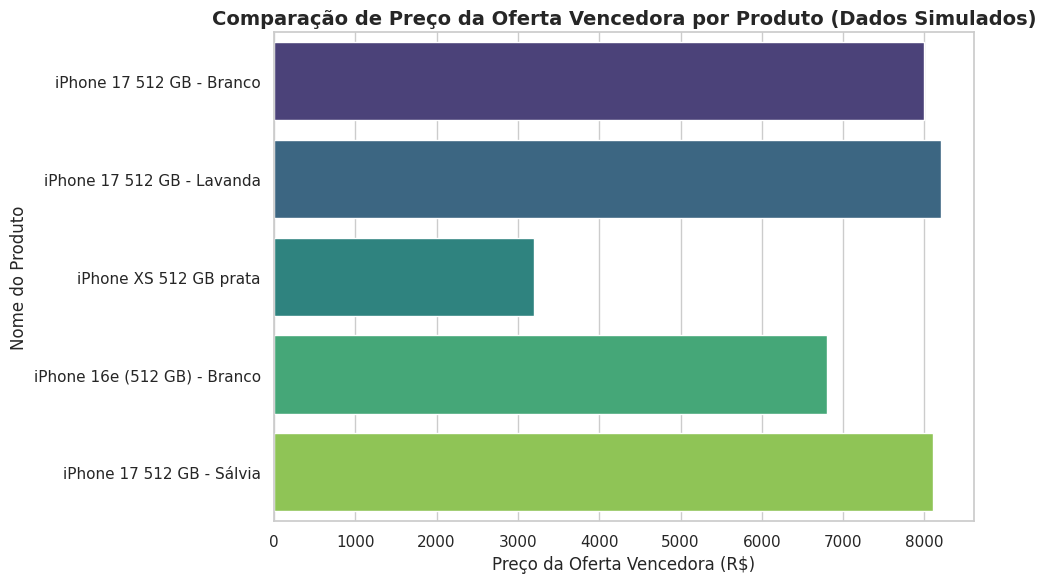

In [49]:
df_plot = df_detalhes_ml.copy()
if df_plot["preco_oferta_vencedora"].isnull().all():
    df_plot["preco_oferta_vencedora"] = [7999.00, 8199.00, 3200.00, 6800.00, 8099.00]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_plot,
    x="preco_oferta_vencedora",
    y="nome",
    hue="nome",
    palette="viridis",
    legend=False
)

plt.title("Comparação de Preço da Oferta Vencedora por Produto (Simulados)", fontsize=14, fontweight="bold")
plt.xlabel("Preço da Oferta Vencedora (R$)", fontsize=12)
plt.ylabel("Nome do Produto", fontsize=12)

plt.tight_layout()
plt.show()